In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.datasets import load_iris
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import roc_curve, roc_auc_score

In [2]:
# =====================================
# STEP 2: Load Dataset
# =====================================

data = load_iris()

X = data.data      # Features
y = data.target    # Target (0 = setosa, 1 = versicolor, 2 = virginica)

# Convert to DataFrame for better visualization
df = pd.DataFrame(X, columns=data.feature_names)
df['target'] = y

df.head()

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),target
0,5.1,3.5,1.4,0.2,0
1,4.9,3.0,1.4,0.2,0
2,4.7,3.2,1.3,0.2,0
3,4.6,3.1,1.5,0.2,0
4,5.0,3.6,1.4,0.2,0


In [3]:
print("Shape of features:", X.shape)
print("Shape of target:", y.shape)

print("\nClass labels:")
print(data.target_names)

Shape of features: (150, 4)
Shape of target: (150,)

Class labels:
['setosa' 'versicolor' 'virginica']


In [4]:
# =====================================
# STEP 3: Convert to Binary Classification
# =====================================
# 1 = Setosa
# 0 = Non-Setosa

y_binary = np.where(y == 0, 1, 0)

In [5]:
# =====================================
# STEP 4: Select Only Sepal Length & Petal Width
# =====================================

# Sepal Length = column 0
# Petal Width  = column 3

X_selected = X[:, [0, 3]]

In [6]:
# =====================================
# STEP 5: Train-Test Split
# =====================================

X_train, X_test, y_train, y_test = train_test_split(
    X_selected, y_binary, test_size=0.2, random_state=42
)

In [7]:
# =====================================
# STEP 6: Feature Scaling
# =====================================

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [8]:
# =====================================
# STEP 7: Train Logistic Regression Model
# =====================================

model = LogisticRegression()

model.fit(X_train_scaled, y_train)

LogisticRegression()

In [9]:
# =====================================
# STEP 8: Make Predictions
# =====================================

y_pred = model.predict(X_test_scaled)

print("First 10 Predictions:", y_pred[:10])
print("Actual Values:", y_test[:10])

First 10 Predictions: [0 1 0 0 0 1 0 0 0 0]
Actual Values: [0 1 0 0 0 1 0 0 0 0]


In [10]:
# =====================================
# STEP 9: Evaluation
# =====================================

accuracy = accuracy_score(y_test, y_pred)
cm = confusion_matrix(y_test, y_pred)

print("Accuracy:", accuracy)
print("\nConfusion Matrix:\n", cm)

print("\nClassification Report:\n")
print(classification_report(y_test, y_pred))

Accuracy: 1.0

Confusion Matrix:
 [[20  0]
 [ 0 10]]

Classification Report:

              precision    recall  f1-score   support

           0       1.00      1.00      1.00        20
           1       1.00      1.00      1.00        10

    accuracy                           1.00        30
   macro avg       1.00      1.00      1.00        30
weighted avg       1.00      1.00      1.00        30



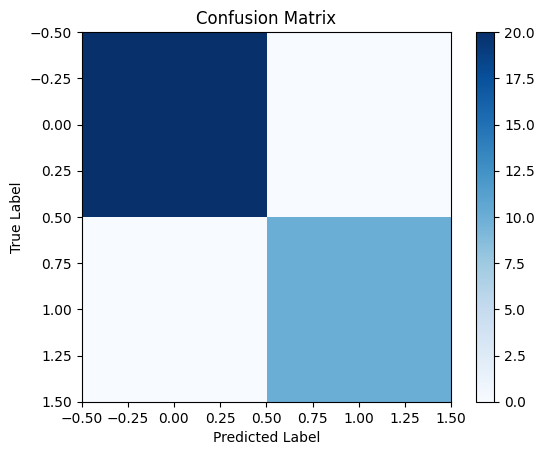

In [11]:
# =====================================
# STEP 10: Plot Confusion Matrix
# =====================================

plt.figure()
plt.imshow(cm, cmap='Blues')
plt.title("Confusion Matrix")
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.colorbar()
plt.show()

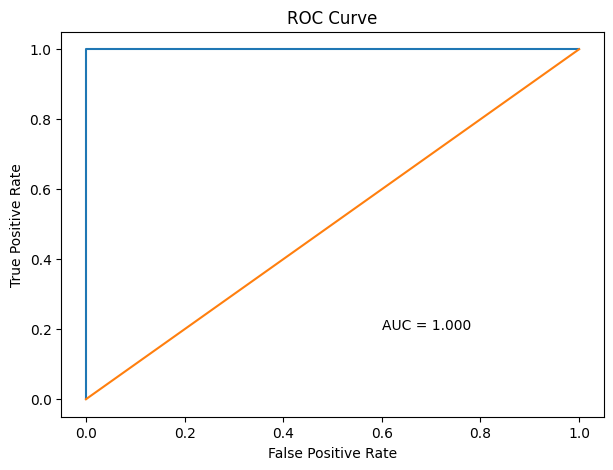

In [12]:
# =====================================
# STEP 11: ROC Curve
# =====================================

# Get probability for class 1 (Setosa)
y_prob = model.predict_proba(X_test_scaled)[:, 1]

fpr, tpr, thresholds = roc_curve(y_test, y_prob)
auc_score = roc_auc_score(y_test, y_prob)

plt.figure(figsize=(7,5))
plt.plot(fpr, tpr)
plt.plot([0,1], [0,1])   # Diagonal reference line

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.text(0.6, 0.2, "AUC = {:.3f}".format(auc_score))

plt.show()